In [26]:
%matplotlib inline
import numpy as np
import Bayessian_quadratures
import GP_regressors
import scipy 
import scipy.integrate as integrate
import QGP_quadratures
from scipy.stats import pareto
import matplotlib.pyplot as plt
## latex font
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': 15})

### Bayesian quadrature implementation
The objective is to perform the integration of a function $f(x)$ over some domain $\Omega$ and a weight funciton $\mu(x)$. This is
$$
\int_{\Omega} f(x)\mu(x)dx
$$

The method proposed is based on the Gaussian Process quadrature, which uses a Gaussian prior of the function $f$ such that its integral can be approximated as

$$\begin{aligned}
Q_{\mathrm{BQ}}(f) & :=\mathbb{E}[\mu(f) \mid \mathcal{D}]=k_\mu(\mathcal{X})^{\top}(\mathbf{K} + \sigma_n^2 I)^{-1} \mathbf{y} , \\
V_{\mathrm{BQ}} & :=\operatorname{Var}[\mu(f) \mid \mathcal{D}]=\mu\left(k_\mu\right)-k_\mu(\mathcal{X})^{\top} (\mathbf{K} + \sigma_n^2 I)^{-1} k_\mu(\mathcal{X}),
\end{aligned}$$

Where $k_\mu(\cdot) = \int k(\cdot,x)\mu(x)dx$ and $\mu\left(k_\mu\right) = \int\int K(x,x')\mu(x) dx \mu(x') dx'$

Let's consider the exponential kernel in a one dimensional example

$$
k(x,x') = \alpha e^{-\frac{1}{2\ell^2}(x-x')^2}
$$

Which will be used to integrate a function of the form
$$
\int_{a}^{b} f(x)dx
$$

Then, we consider a measurement space with weight $\mu(x) = 1$. Then we have,

$$\begin{aligned}
k_\mu(x) &= \int_{a}^{b} k(x,x')\mu(x')dx'\\
&= \int_{a}^{b}\alpha e^{-\frac{1}{2\ell^2}(x-x')^2}dx' \\
&= \ell\alpha\sqrt{\frac{\pi}{2}}\left\{\operatorname{erf}\left(\frac{x-a}{\sqrt{2}\ell}\right) - \operatorname{erf}\left(\frac{x-b}{\sqrt{2}\ell}\right)\right\}
\end{aligned}$$

Also we need the integral of the kernel over both variables

$$\begin{aligned}
\mu(k_\mu) &= \int_{a}^{b}\int_{a}^{b} k(x,x')\mu(x')\mu(x)dx'dx\\
&= \int_{a}^{b}\int_{a}^{b}\alpha e^{-\frac{1}{2\ell^2}(x-x')^2}dx'dx \\
&= 2\alpha\ell\left(\ell\left(e^{-\frac{(a-b)^2}{2\ell^2}} - 1\right) + \sqrt{\frac{\pi}{2}}(a-b)\operatorname{erf}\left(\frac{a-b}{\sqrt{2}\ell}\right)\right)
\end{aligned}$$


In [27]:
##This function makes the plots easy  
def plot_with_uncertainty(Xp, mu, Sigma, color='r', title="", name = "Mean", linewidth=2.0, linestyle='-', marker = None):
    
    mean, std = mu.ravel(), np.sqrt(np.diag(Sigma))

    # plot distribution
    plt.plot(Xp, mean, color=color,  label=name, linewidth=linewidth, linestyle=linestyle, marker = marker)
    plt.fill_between(Xp.ravel(), mean - 2*std, mean + 2*std, color=color, alpha=0.25)
    
    plt.title(title)

def gaussian_pdf(x, mean, variance):
    std = np.sqrt(variance)
    return np.exp(-0.5*((x-mean)/std)**2)/(std*np.sqrt(2*np.pi))
## function to plot a gaussian with mean, variance and color filling
def plot_gaussian(mean, variance, color, label, intensity=1):
    std = np.sqrt(variance)
    ## plot a gaussian probability density function with mean and variance

    means = np.linspace(mean - 3*std, mean + 3*std, 100)
    pdf = gaussian_pdf(means, mean, variance)
    plt.plot(means, pdf, color, label=label, alpha=intensity)
    plt.fill_between(means, pdf, color=color, alpha=0.25*intensity)
    ## plot vertical line at the mean until the pdf
    plt.vlines(x = mean, ymax = max(pdf), ymin=0, color=color, alpha=intensity)

    plt.legend()
    
    

## Example $f(x) $ 

In [28]:
def pareto_loss(x, shape=3.0, scale=1.0):
    """Pareto loss function"""
    return (pareto.pdf(x, b=shape, scale=scale) * (x - scale))*(x-1)

In [29]:
from scipy.stats import pareto
from scipy.integrate import quad
import numpy as np

# Pareto parameters
pareto_shape = 3.0
pareto_scale = 1.0

# Define Pareto pdf
f = lambda x: pareto.pdf(x, b=pareto_shape, scale=pareto_scale)

# Integrate from the lower support bound to 10
result, err = quad(f, pareto_scale, 10)

In [39]:
## Problem definition
## interval definition
x_i = 1.0
x_f = 10
pareto_shape = 3.0
pareto_scale = x_i
domain = [x_i, x_f]
X_real = np.linspace(start=x_i, stop=x_f, num=50)
y = np.squeeze(pareto_loss(X_real, shape=pareto_shape, scale=pareto_scale))
f = lambda x: pareto.pdf(x, b=pareto_shape, scale=pareto_scale)
result, err = quad(f, pareto_scale, x_f)
## Points for GPR and visualice the function
Xp = np.linspace(start=x_i, stop=x_f, num=50).reshape(-1, 1)

## Number of evaluation points
np.random.seed(679)
N =2**4

X_eval = np.linspace(start=x_i, stop=x_f, num=N).reshape(-1, 1)
y_eval = np.squeeze(pareto_loss(X_eval, shape=pareto_shape, scale=pareto_scale))
## Noise addition, this is noise in the measurements
noise_std = 0.05

y_eval = y_eval+ np.random.normal(0.0, noise_std, size=y_eval.shape)

sigma2 = noise_std**2

We have already derived the equations for the Hilbert space approximation of the Gaussian process quadrature. The result gives

$$\begin{aligned}
Q_{\mathrm{BQ}}(f) & \approx \Phi_\mu^{\top}(\Phi^{\top}\Phi + \sigma_n^2 \Lambda^{-1})^{-1}\Phi^{\top} \mathbf{y} , \\
V_{\mathrm{BQ}} & \approx \sigma_n^2 \Phi_\mu^{\top}(\Phi^{\top}\Phi + \sigma_n^2 \Lambda^{-1})^{-1}\Phi_{\mu} ,
\end{aligned}$$

Where the vector $\Phi_\mu$ has components

$$
{\Phi_{\mu}}_i = \int_\Omega \phi_i(x)d\mu(x).
$$

The matrices and vectors needed are built the  `Bayessian_quadratures.py` file.

In [40]:
## Problem definition
## interval definition



X_real = np.linspace(start=x_i, stop=x_f, num=1000).reshape(-1, 1)
y = np.squeeze(pareto_loss(X_real, shape=pareto_shape, scale=pareto_scale))

## Points for GPR and visualice the function
Xp = np.linspace(start=x_i, stop=x_f, num=50).reshape(-1, 1)

## Number of evaluation points
np.random.seed(679)
#N =8

X_eval = np.linspace(start=x_i, stop=x_f, num=N).reshape(-1, 1)
y_eval = np.squeeze(pareto_loss(X_eval, shape=pareto_shape, scale=pareto_scale))
## Noise addition, this is noise in the measurements
noise_std = 0.05

y_eval = y_eval+ np.random.normal(0.0, noise_std, size=y_eval.shape)

sigma2 = noise_std**2

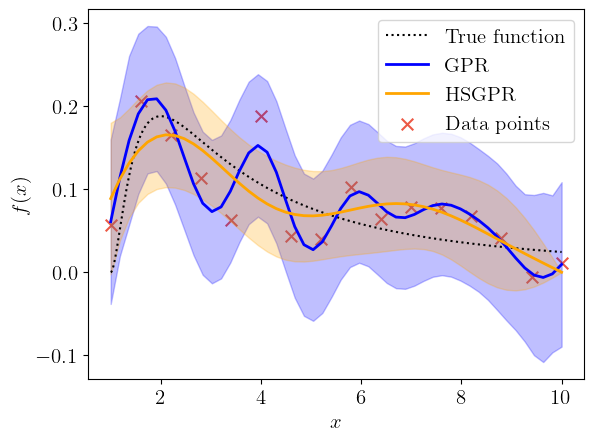

<Figure size 640x480 with 0 Axes>

In [41]:
#Models for regression
alpha = 1.0
scale = 1.0

L = 10
M = 2**3

## Exponential kernel regression to visualize the GPR of the function
GK = GP_regressors.Gaussian_kernel_GPR((X_eval, y_eval ),sigma2=sigma2, alpha=alpha, scale=scale)
HS = GP_regressors.HS_approx_GPR((X_eval, y_eval ),sigma2=sigma2,L=L, M=M, alpha=alpha, scale=scale)

mu_post_exp_k, Sigma_post_exp_k = GK.posterior(Xp)
mu_post_approx_HS_k, Sigma_post_approx_HS_k = HS.posterior(Xp)

## Plotting
plt.plot(X_real, y, label="True function", linestyle="dotted", color='k')
plot_with_uncertainty(Xp, mu_post_exp_k, Sigma_post_exp_k, color='blue', name = "GPR")
plot_with_uncertainty(Xp, mu_post_approx_HS_k, Sigma_post_approx_HS_k, color='orange', name = "HSGPR")

plt.scatter(X_eval, y_eval , marker='x', label="Data points", color='#e82f17',zorder=0, s = 70, alpha=0.8)

plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.legend()

plt.show()

plt.savefig("GPR_exp_kernel.pdf", bbox_inches='tight')


In [42]:
## Class for the Quadrature using the classical method

GPQ = Bayessian_quadratures.Gaussian_process_quadrature((X_eval, y_eval),
                                                        sigma2=sigma2, 
                                                        alpha=alpha, 
                                                        scale=scale, 
                                                        domain= domain)
HSQ = Bayessian_quadratures.Sine_HSQ((X_eval, y_eval ),
                                                sigma2=sigma2, 
                                                M=M, 
                                                L=L, 
                                                alpha=alpha, 
                                                scale=scale,
                                                domain= domain)

mu_post_GPQ, Sigma_post_GPQ = GPQ.quadrature_posterior()
mu_post_HSQ, Sigma_post_HSQ = HSQ.quadrature_posterior()






scale_factor = (0.4/result)
## integrate
I = integrate.quad(lambda x: pareto_loss(x, shape=pareto_shape, scale=pareto_scale), x_i, x_f)
print("Real integral: ", scale_factor * I[0])

print("Integral approximation: ", scale_factor   * mu_post_GPQ)
print("Integral approximation error: ", scale_factor * np.sqrt(Sigma_post_GPQ))
print("Integral approximation HS: ", scale_factor * mu_post_HSQ)
print("Integral approximation error HS: ", scale_factor * np.sqrt(Sigma_post_HSQ))


X_mu [ 2.67217546 -3.03353603  1.46135215 -0.13787854  0.16002607 -0.67549715
  0.63643153 -0.18550255]
Real integral:  0.29189189189189185
Integral approximation:  [0.30953426]
Integral approximation error:  [[0.04633134]]
Integral approximation HS:  [0.30698522]
Integral approximation error HS:  0.04496122549073036


In [47]:
## evaluate the problem for N in [2, 3,4,5,6,7,8,9,10,11,12,13,14,15,16]


n_eig=15
shots = 1000000
N_sim = 5
#R =2
del_params = 0.009


rank_range = [4]

mean_avg_R = []
std_avg_R  = []

mean_med_R = []
std_med_R  =[]


for R in rank_range:
    means_q_list = []
    vars_q_list  = []


    for sim in range(N_sim):
        np.random.seed(679)


        ## implementation using quantum circuit





        X_eval = np.linspace(start=x_i, stop=x_f, num=N).reshape(-1, 1)
        y_eval = np.squeeze(pareto_loss(X_eval, shape=pareto_shape, scale=pareto_scale))
        ## Noise addition, this is noise in the measurements
        noise_std = 0.05

        y_eval = y_eval+ np.random.normal(0.0, noise_std, size=y_eval.shape)

        sigma2 = noise_std**2


        GPQ = Bayessian_quadratures.Gaussian_process_quadrature((X_eval, y_eval),
                                                        sigma2=sigma2, 
                                                        alpha=alpha, 
                                                        scale=scale, 
                                                        domain= domain)
        HSQ = Bayessian_quadratures.Sine_HSQ((X_eval, y_eval ),
                                                sigma2=sigma2, 
                                                M=M, 
                                                L=L, 
                                                alpha=alpha, 
                                                scale=scale,
                                                domain= domain)

        mu_post_GPQ, Sigma_post_GPQ = GPQ.quadrature_posterior()
        mu_post_HSQ, Sigma_post_HSQ = HSQ.quadrature_posterior()

        means_GPQ = mu_post_GPQ
        stds_GPQ = np.sqrt(Sigma_post_GPQ)

        means_HSQ = mu_post_HSQ
        stds_HSQ  = np.sqrt(Sigma_post_HSQ)

        Phif = HSQ.Phi_matrix(X_eval).T
        Lambda = HSQ.Lambda()


        Z = np.array(Phif.T @ np.sqrt(Lambda))

        ## Normalize the data
        norm_z = np.linalg.norm(Z)

        Z_norm = Z/norm_z

        ZZd = np.array(Z_norm.T @ Z_norm)

        ## sigular value decomposition ZZd
        U, S, V = np.linalg.svd(Z_norm)
        real_eigenvals, real_eigenvecs = scipy.linalg.eig(ZZd)
        real_eigenvals = np.sort(real_eigenvals)[::-1]


        '''
        The delta parameter is important for accurately estimating the eigenvalues. The performance of the algorithm
        is very sensitive to the choice of delta. The delta parameter should be 1>delta>lam_max, 
        for demonstrations purposes we choose delta = lam_max + 0.012
        '''
        delta = np.real(real_eigenvals[0])+del_params



        mean_args_post = [X_eval, y_eval, sigma2, M, L, alpha, scale, domain, delta, n_eig, R, shots]
        mu_post_approx_HS_k_QPU, Sigma_post_approx_HS_k_QPU, qc_swap = QGP_quadratures.QGPQ_approximation_posterior(mean_args_post)
        means_q= mu_post_approx_HS_k_QPU
        stds_q = np.sqrt(Sigma_post_approx_HS_k_QPU)
        means_q_list.append(means_q)
        vars_q_list.append(Sigma_post_approx_HS_k_QPU)
        
        means_q_arr = np.array(means_q_list)
        vars_q_arr  = np.array(vars_q_list)

        # average
    mean_avg = np.mean(means_q_arr)
    var_avg  = np.mean(vars_q_arr)

    # median
    mean_med = np.median(means_q_arr)
    var_med  = np.median(vars_q_arr)

    # store
    mean_avg_R.append(mean_avg)
    std_avg_R.append(np.sqrt(var_avg))

    mean_med_R.append(mean_med)
    std_med_R.append(np.sqrt(var_med))

                    #print("R: ", R)
                    #print("Integral approximation QHS: ", mu_post_approx_HS_k_QPU)
                    #print("Integral approximation error QHS: ", np.sqrt(Sigma_post_approx_HS_k_QPU))
                    
            
            #print("Integral approximation HS: ", mu_post_HSQ)
            #print("Integral approximation error HS: ", np.sqrt(Sigma_post_HSQ))
            #print("Delta: ", delta)


X_mu [ 2.67217546 -3.03353603  1.46135215 -0.13787854  0.16002607 -0.67549715
  0.63643153 -0.18550255]
Real eigenvalues bef:  [3.40568854e-01+0.j 2.92410009e-01+0.j 2.25832283e-01+0.j
 1.32766486e-01+0.j 8.38189990e-03+0.j 4.04319161e-05+0.j
 3.57039413e-08+0.j 4.72695254e-12+0.j]
Real eigenvalues after:  [3.40568854e-01+0.j 2.92410009e-01+0.j 2.25832283e-01+0.j
 1.32766486e-01+0.j 8.38189990e-03+0.j 4.04319161e-05+0.j
 3.57039413e-08+0.j 4.72695254e-12+0.j]
Quantum eigenvalues:  [0.34056506676426507, 0.29240973812832055, 0.22583078243117174, 0.13276319558580624, 0.01969311844527106, 0.008385043931735132, 4.267197929636199e-05, 1.0667994824090498e-05]
Quantum eigenvalues keys:  ['111110010110100', '110101100010010', '101001010110001', '011000010011101', '000011100110110', '000001100010010', '000000000000100', '000000000000001']
X_mu [ 2.67217546 -3.03353603  1.46135215 -0.13787854  0.16002607 -0.67549715
  0.63643153 -0.18550255]
Real eigenvalues bef:  [3.40568854e-01+0.j 2.92410009e-

In [48]:



print("===== Rank Dependent Results =====")


for i, R in enumerate(rank_range):

    print(f"\nRank R = {R}")

    print("Average Mean     :", scale_factor*mean_avg_R[i])
    print("Average Std Dev  :", scale_factor*std_avg_R[i])

    print("Median Mean      :", scale_factor*mean_med_R[i])
    print("Median Std Dev   :", scale_factor*std_med_R[i])


===== Rank Dependent Results =====

Rank R = 4
Average Mean     : 0.27205250511609746
Average Std Dev  : 0.05830050888561609
Median Mean      : 0.272404700911583
Median Std Dev   : 0.05830050888561609


In [51]:
scale_factor*mean_med_R[0]

0.272404700911583

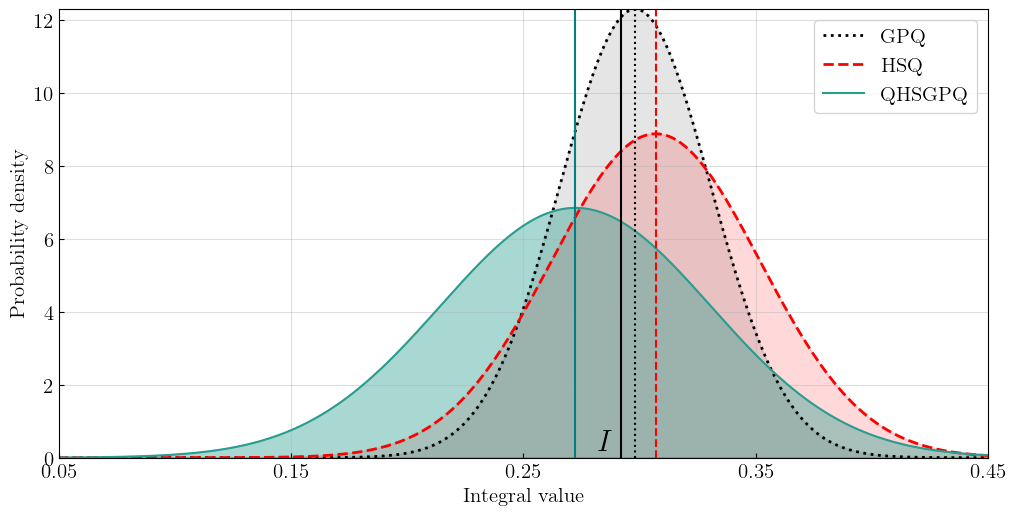

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# x–axis range
x = np.linspace(-0.1, 0.6, 1000)

# Mean and std values (example – replace with your results)
mu_gpq, sigma_gpq =0.29815237, 0.0324706
mu_hsq, sigma_hsq = 0.30698522, 0.04496122549073036

mu_qhsq1, sigma_qhsq1 = scale_factor*mean_med_R[0], scale_factor*std_med_R[0]
#mu_qhsq2, sigma_qhsq2 = scale_factor*mean_med_R[1], scale_factor*std_med_R[1]
#mu_qhsq3, sigma_qhsq3 = scale_factor*mean_med_R[2], scale_factor*std_med_R[2]
#mu_qhsq4, sigma_qhsq4 = 6.27, 0.10

# Compute PDFs
pdf_gpq  = norm.pdf(x, mu_gpq, sigma_gpq)
pdf_hsq  = norm.pdf(x, mu_hsq, sigma_hsq)
pdf_q1   = norm.pdf(x, mu_qhsq1, sigma_qhsq1)
#pdf_q2   = norm.pdf(x, mu_qhsq2, sigma_qhsq2)
#pdf_q3   = norm.pdf(x, mu_qhsq3, sigma_qhsq3)
#pdf_q4   = norm.pdf(x, mu_qhsq4, sigma_qhsq4)

plt.figure(figsize=(10,5))

# GPQ
plt.plot(x, pdf_gpq, 'k:', linewidth=2, label='GPQ')
plt.fill_between(x, pdf_gpq, color='gray', alpha=0.2)

# HSQ
plt.plot(x, pdf_hsq, 'r--', linewidth=2, label='HSQ')
plt.fill_between(x, pdf_hsq, color='red', alpha=0.15)

# QHSQ curves
#plt.plot(x, pdf_q1, color='#a8dadc', label='QHSQ R=1')
#plt.fill_between(x, pdf_q1, color='#a8dadc', alpha=0.4)

plt.plot(x, pdf_q1, color='#2a9d8f', label='QHSGPQ')
plt.fill_between(x, pdf_q1, color='#2a9d8f', alpha=0.4)

#plt.plot(x, pdf_q3, color='#2a9d8f', label='QHSQ R=3')
#plt.fill_between(x, pdf_q3, color='#2a9d8f', alpha=0.4)


# Vertical mean lines
plt.axvline(mu_gpq,  color='black', linestyle=':')
plt.axvline(mu_hsq,  color='red', linestyle='--')
plt.axvline(mu_qhsq1, color='teal')

# Mark I1
I1 = scale_factor * I[0]
plt.axvline(I1, color='black')
plt.text(I1-0.01, 0.2, r'$I$', fontsize=22)
plt.xlim(0.05, 0.45)
# Labels
plt.xlabel('Integral value')
plt.ylabel('Probability density')

plt.tick_params(direction='in')
plt.xticks([0.05, 0.15, 0.25, 0.35, 0.45])
#plt.xticks(list(plt.xticks()[0]) + [I[0]], list(plt.xticks()[0]) + [r'$\mathcal{I}_1$'])
plt.legend(loc="upper right")
plt.margins(0)
plt.legend()
plt.grid(alpha=0.4)
plt.savefig("Simulation.pdf", dpi=1200, bbox_inches='tight')
plt.tight_layout(pad=0.1)
plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 1

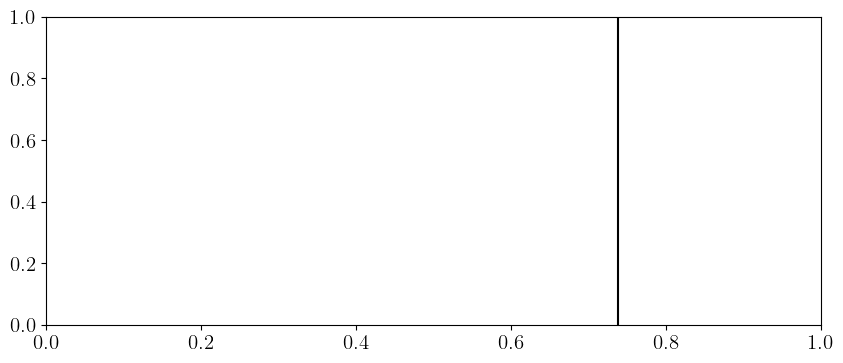

In [10]:
## Gaussian distributions plot
color_HSQ = "#8f0606"
color_QHSQ = "#008080"
color_GPQ = "k"
## Plotting
fig = plt.figure(figsize=(10, 4))
## vertical line at the real integral
plt.axvline(x=I[0],  color='k', linestyle='-', linewidth=1.5)


## Gaussian PQ
plot_gaussian(means_GPQ[6], stds_GPQ[6]**2, color=color_GPQ, label="GPQ", intensity=1, linestyle=':')
## Gaussian HSQ
plot_gaussian(means_HSQ[6], stds_HSQ[6]**2, color=color_HSQ, label="HSQ", intensity=1, linestyle='--')

## quantum approximations
plt.ylim(0, 3.6)
plt.xlabel("Integral value")
plt.ylabel("Probability density")
for R in [1,2,3,4]:
    plot_gaussian(means_q[6, R-1, 0], stds_q[6, R-1, 0]**2, color=color_QHSQ, label="QHSQ R={}".format(R), intensity=(R/4)**1.7, linestyle='-')

plt.tick_params(direction='in')
plt.xticks([ 5.6, 5.8, 6.0, 6.2, 6.4, 6.6, 6.8])
plt.xticks(list(plt.xticks()[0]) + [I[0]], list(plt.xticks()[0]) + [r'$\mathcal{I}_1$'])
plt.legend(loc="upper right")

plt.xlim(5.58, 6.7)

## add xtick with the real integral value and label 

plt.tight_layout()
plt.savefig("Figures/integral_gaussian_distribution.pdf")
plt.show()  


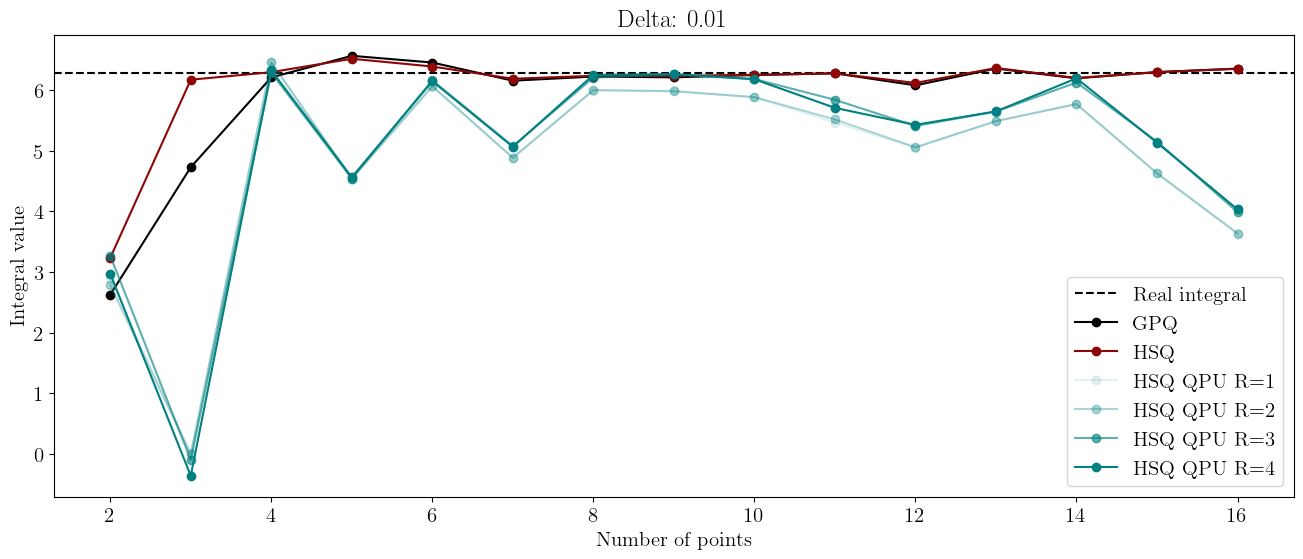

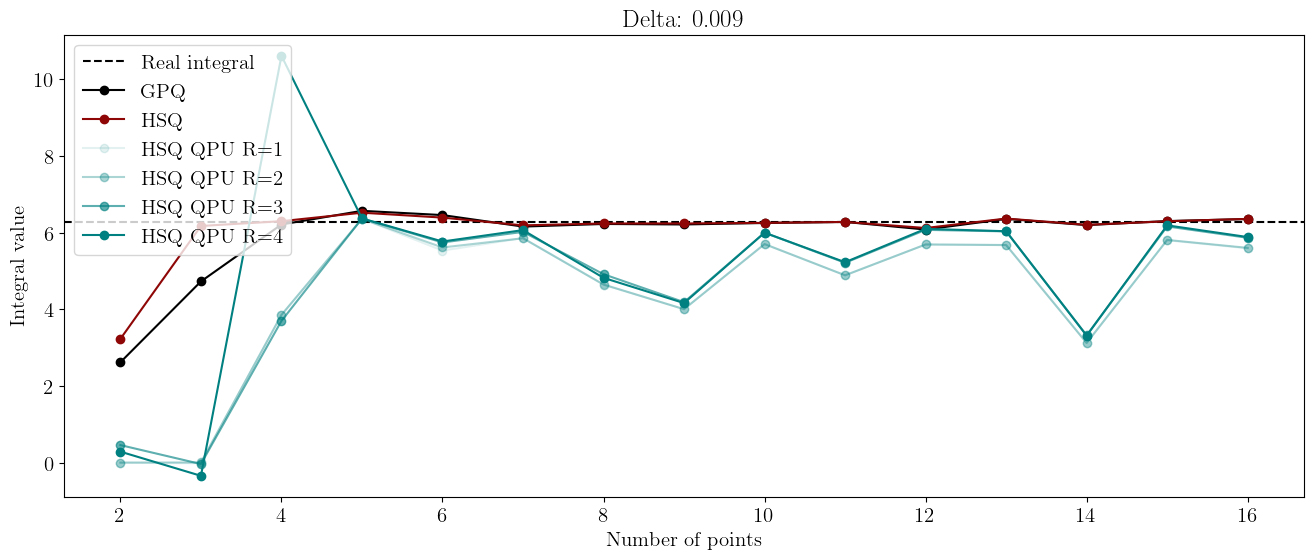

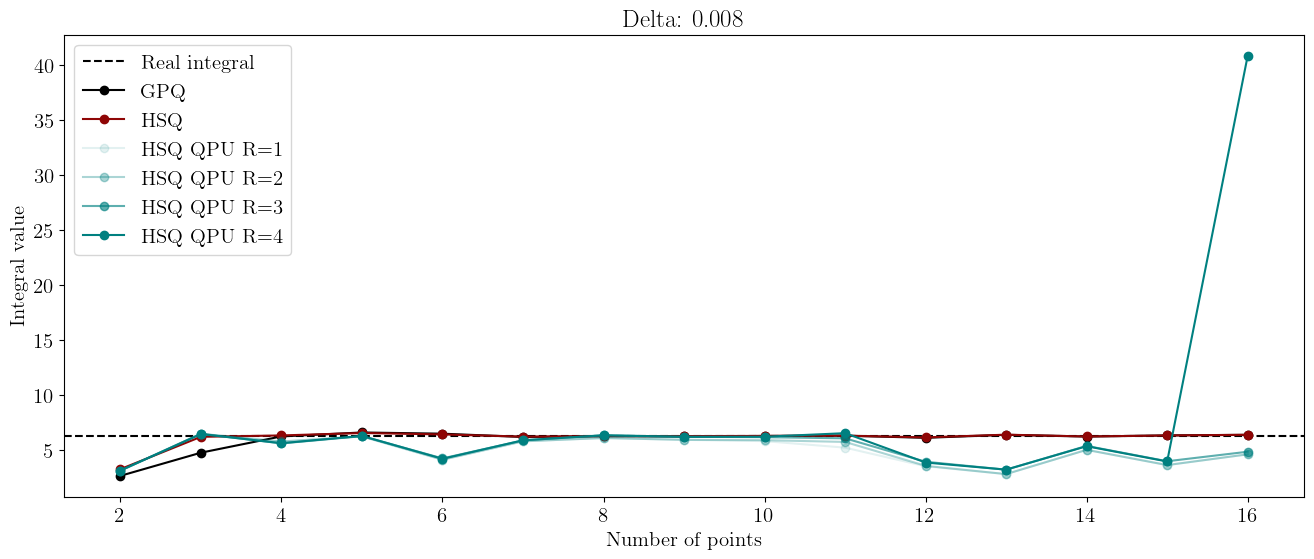

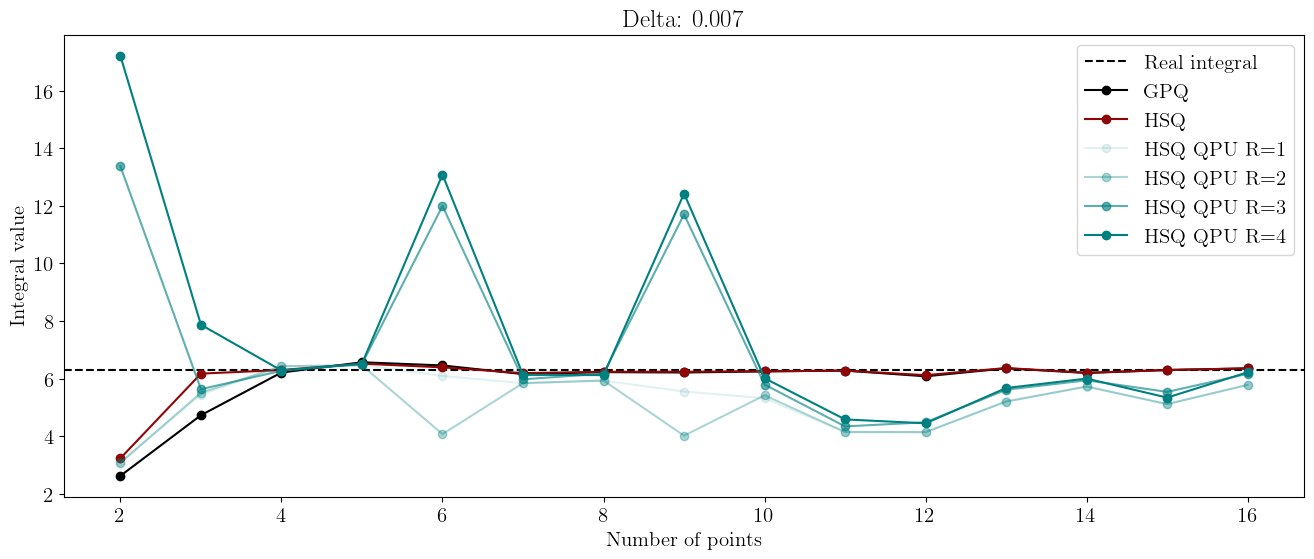

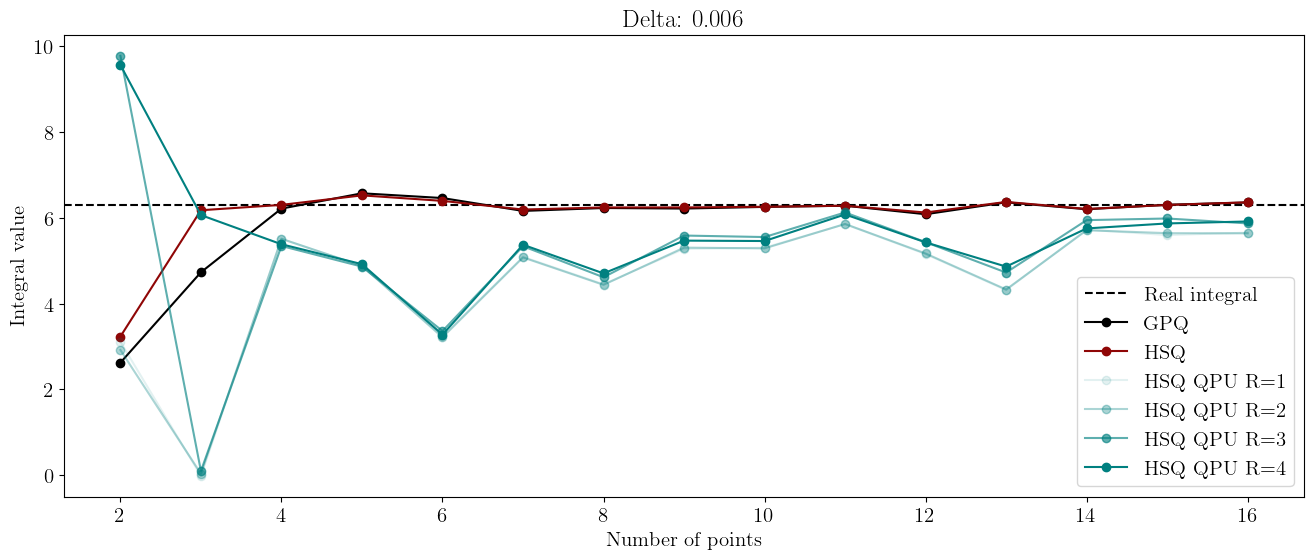

In [19]:

## Plotting for every delta
for j in range(len(del_params)):
    fig = plt.figure(figsize=(16, 6))
## horixontal line at the real integral
    plt.axhline(y=I[0], color='k', linestyle='--', label="Real integral")

    plt.ylabel("Integral value")
    plt.xlabel("Number of points")
    plt.plot(Ns, means_GPQ, color=color_GPQ, label="GPQ", linestyle='-', marker='o') 
    plt.plot(Ns, means_HSQ, color= color_HSQ, label="HSQ", linestyle='-', marker='o')
    for R in Rs:
        plt.plot(Ns, means_q[:, R-1, j], color=color_QHSQ, label="HSQ QPU R={}".format(R), linestyle='-', marker='o', alpha=(R/4)**1.6)
    plt.title("Delta: {}".format(del_params[j]))
    plt.legend()
    plt.show()

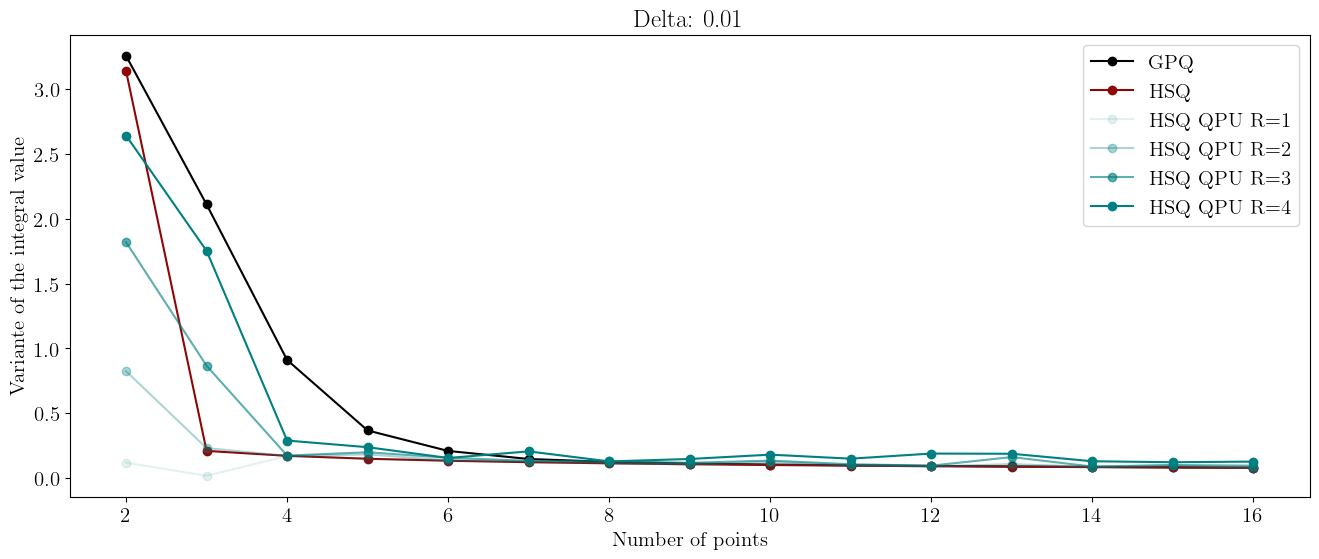

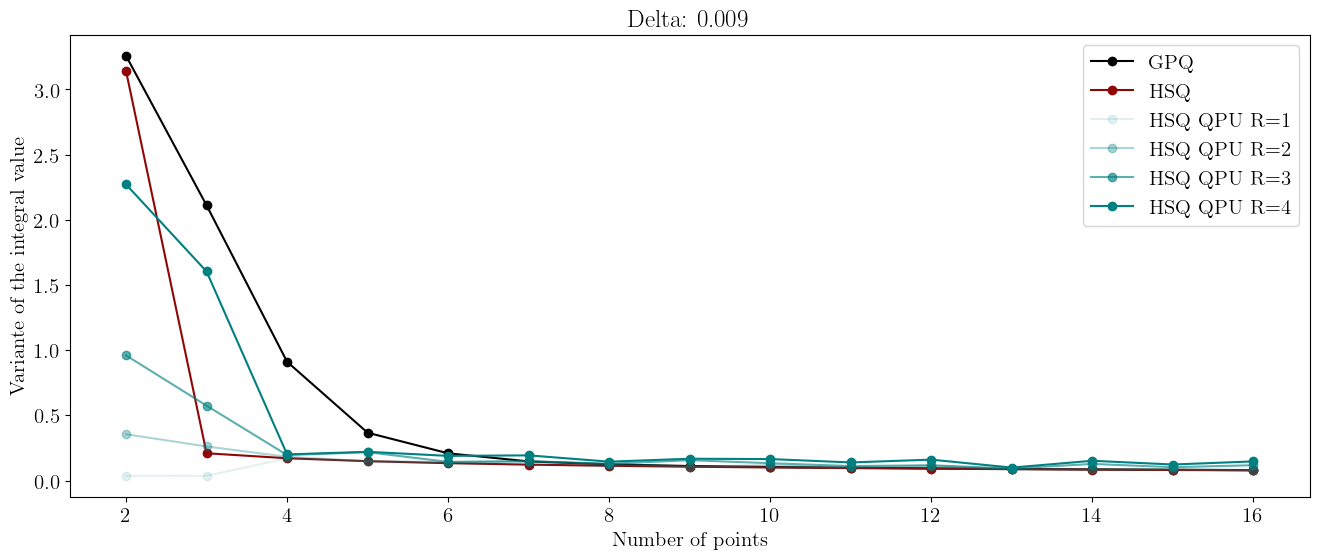

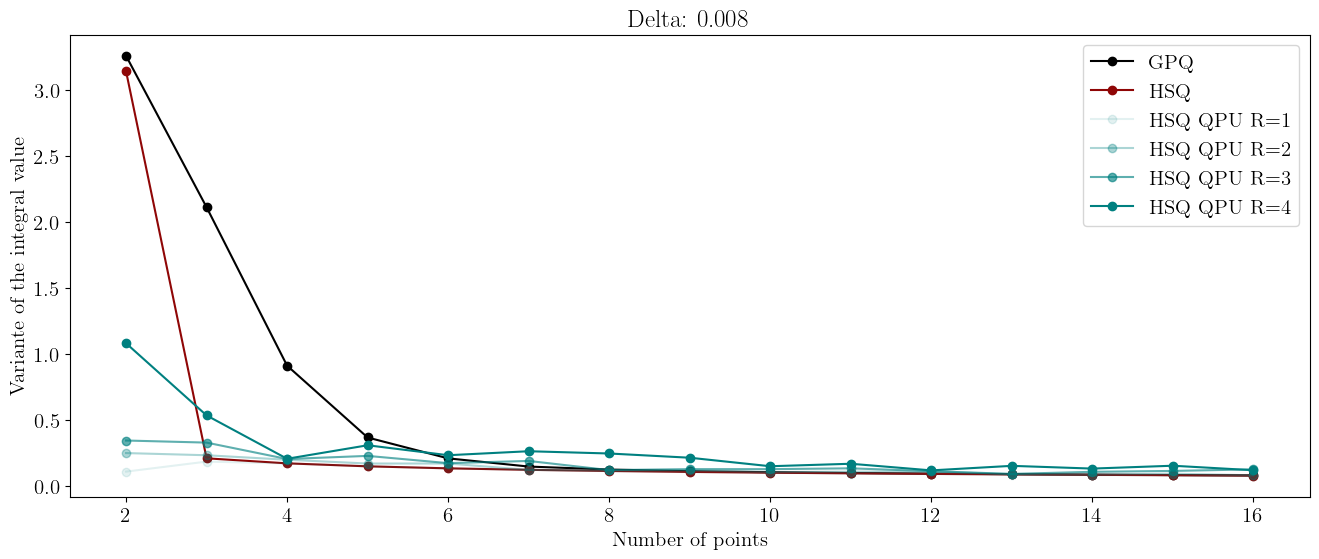

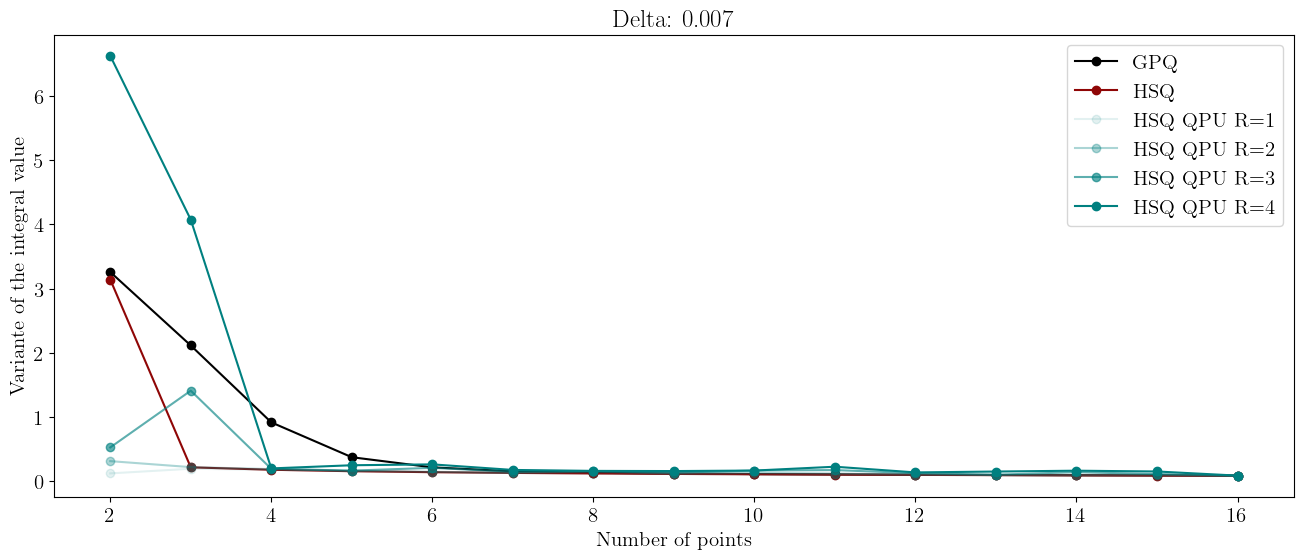

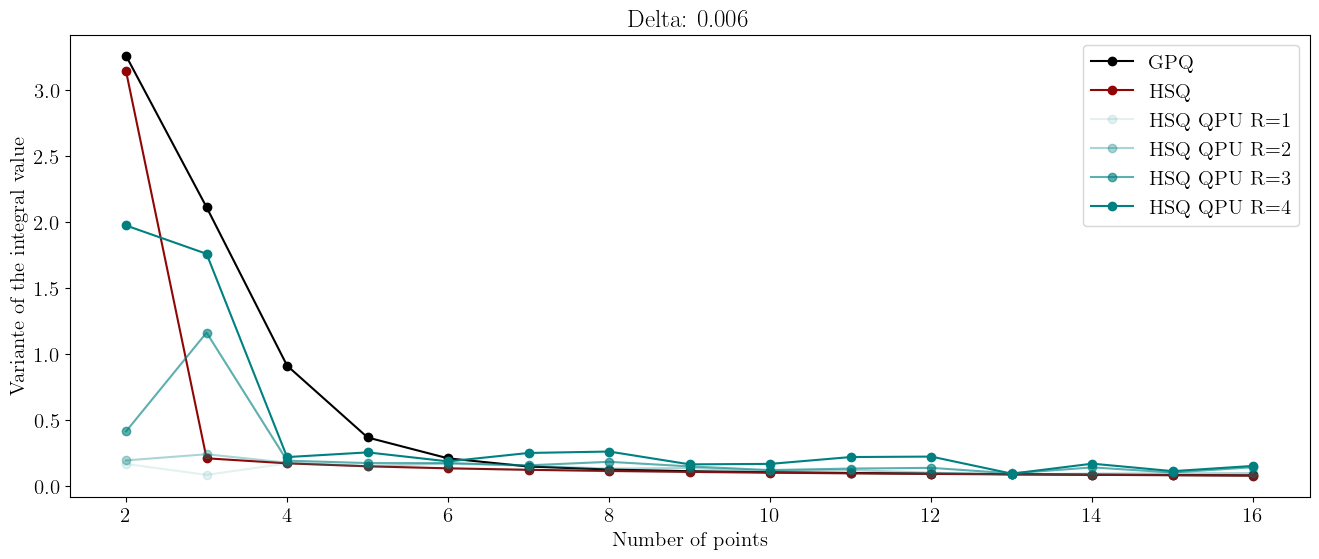

In [20]:
## Plotting for every delta variance
for j in range(len(del_params)):
    fig = plt.figure(figsize=(16, 6))

    plt.ylabel("Variante of the integral value")
    plt.xlabel("Number of points")
    plt.plot(Ns, stds_GPQ, color=color_GPQ, label="GPQ", linestyle='-', marker='o')
    plt.plot(Ns, stds_HSQ, color=color_HSQ, label="HSQ", linestyle='-', marker='o')
    for R in Rs:
        plt.plot(Ns, stds_q[:, R-1, j],  color=color_QHSQ, label="HSQ QPU R={}".format(R), linestyle='-', marker='o', alpha=(R/4)**1.6)
    plt.title("Delta: {}".format(del_params[j]))
    plt.legend()
    plt.show()

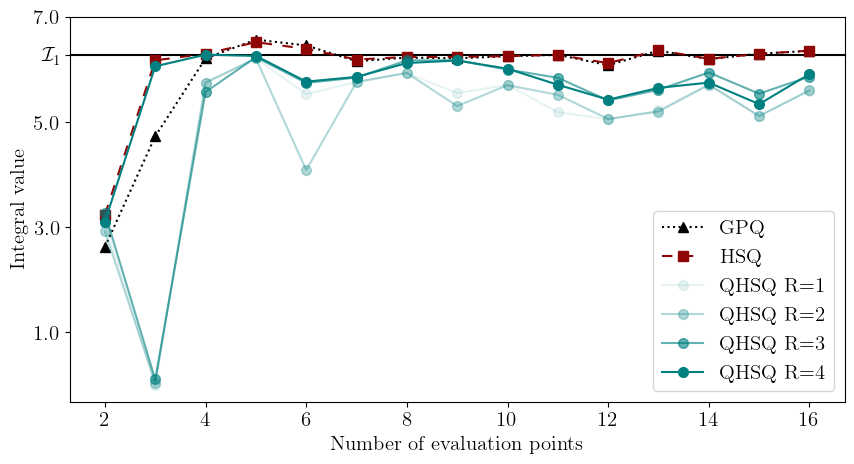

In [22]:
## take the median over the delta parameters
means_q_media = np.median(means_q, axis=2)

## Plotting for every R
fig = plt.figure(figsize=(10, 5))

## horizontal line at the real integral
plt.axhline(y=I[0], color='k', linestyle='-', linewidth=1.5)


plt.ylabel("Integral value")
plt.xlabel("Number of evaluation points")
## plot the mean against the number of evaluation points
plt.plot(Ns, means_GPQ, color = color_GPQ,label="GPQ", linestyle=':', marker='^', markersize=7)
plt.plot(Ns, means_HSQ, color = color_HSQ,label="HSQ", linestyle='--', marker='s', markersize=7, dashes=(5, 5))
for R in Rs:
    plt.plot(Ns, means_q_media[:, R-1],  color=color_QHSQ, label="QHSQ R={}".format(R), linestyle='-', marker='o', markersize=7, alpha=(R/4)**1.7)

#plt.ylim(2.6, 7)
## yticks  = [0.0, 1.0 3.0, 5.0, 7.0]
plt.yticks([ 1.0 ,3.0, 5.0, 7.0])
plt.yticks(list(plt.yticks()[0]) + [I[0]], list(plt.yticks()[0]) + [r'$\mathcal{I}_1$'])

plt.legend()
plt.savefig("Figures/integral_mean.pdf")

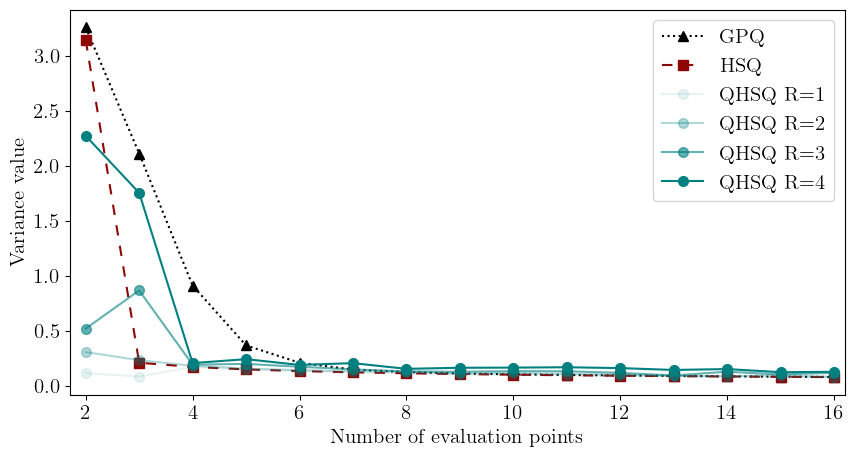

In [23]:
## take the median over the delta parameters
stds_q_media = np.median(stds_q, axis=2)

## Plotting for every R
fig = plt.figure(figsize=(10, 5))


plt.ylabel("Variance value")
plt.xlabel("Number of evaluation points")

plt.plot(Ns, stds_GPQ, color=color_GPQ, label="GPQ", linestyle=':', marker='^', markersize=7)
plt.plot(Ns, stds_HSQ, color=color_HSQ, label="HSQ", linestyle='--', marker='s', markersize=7, dashes=(5, 5))

for R in Rs:
    plt.plot(Ns, stds_q_media[:, R-1],  color=color_QHSQ, label="QHSQ R={}".format(R), linestyle='-', marker='o', markersize=7, alpha=(R/4)**1.7)

plt.legend()
plt.xlim(1.7, 16.2)
plt.savefig("Figures/integral_variance.pdf")


<function matplotlib.pyplot.show(close=None, block=None)>

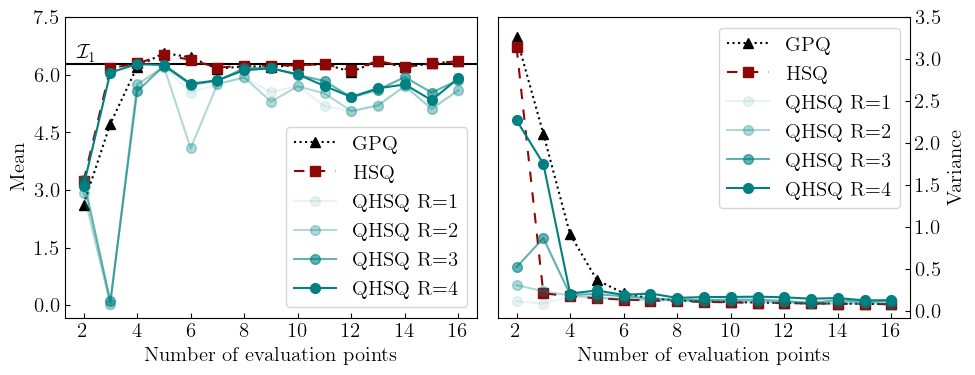

In [24]:
## plot mean and variance beside each other for the paper
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

## horizontal line at the real integral
ax[0].axhline(y=I[0], color='k', linestyle='-', linewidth=1.5)
## plot the mean against the number of evaluation points
ax[0].plot(Ns, means_GPQ, color = color_GPQ,label="GPQ", linestyle=':', marker='^', markersize=7)
ax[0].plot(Ns, means_HSQ, color = color_HSQ,label="HSQ", linestyle='--', marker='s', markersize=7, dashes=(5, 5))
for R in Rs:
    ax[0].plot(Ns, means_q_media[:, R-1],  color=color_QHSQ , label="QHSQ R={}".format(R), linestyle='-', marker='o', markersize=7, alpha=(R/4)**1.7)

ax[0].tick_params(direction='in')
ax[0].set_ylabel("Mean")
ax[0].set_xlabel("Number of evaluation points")
ax[0].set_yticks([ 0 ,1.5, 3.0, 4.5, 6.0, 7.5])
ax[0].set_xticks([ 2 ,4, 6, 8, 10, 12, 14, 16])
ax[0].legend()

plt.text(0.05, 0.88, '$\mathcal{I}_1$', horizontalalignment='center', verticalalignment='center', rotation=0, transform=ax[0].transAxes)

## plot the variance against the number of evaluation points
ax[1].tick_params(direction='in')
ax[1].plot(Ns, stds_GPQ, color = color_GPQ,label="GPQ", linestyle=':', marker='^', markersize=7)
ax[1].plot(Ns, stds_HSQ, color = color_HSQ,label="HSQ", linestyle='--', marker='s', markersize=7, dashes=(5, 5))
for R in Rs:
    ax[1].plot(Ns, stds_q_media[:, R-1],  color=color_QHSQ, label="QHSQ R={}".format(R), linestyle='-', marker='o', markersize=7, alpha=(R/4)**1.7)

ax[1].set_ylabel("Variance")
ax[1].set_xticks([ 2 ,4, 6, 8, 10, 12, 14, 16])
ax[1].set_yticks([ 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])
ax[1].set_xlabel("Number of evaluation points")

ax[1].legend()

## Move ticks to the right in second plot
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")
## tight layout
fig.tight_layout()
## join the two plots, no space in between
plt.subplots_adjust(wspace=0.05)
plt.savefig("Figures/integral_mean_variance.pdf")
plt.show

In [ ]:


 

Created 5 todos

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/gaussian_quantum/quantum_algorithms.py#1-1), lines 1 to 200

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/gaussian_quantum/hilbert_space_approx.py#1-1), lines 1 to 200

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/gaussian_quantum/classical.py)

Starting: *Read the notebook to understand usage* (3/5)

Now let me read the rest of quantum_algorithms.py (the `quantum_hsgp_integral` function) and the rest of hilbert_space_approx.py (the `hsgp_integral` function):  

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/gaussian_quantum/quantum_algorithms.py#200-200), lines 200 to 433

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/gaussian_quantum/hilbert_space_approx.py#160-160), lines 160 to 231

Now let me read the notebook to understand what it actually does: 

Retrieving Notebook summary.

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/Quantum_HSGP_quadrature_Pareto.ipynb#1-1), lines 1 to 100

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/Quantum_HSGP_quadrature_Pareto.ipynb#100-100), lines 100 to 250

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/Quantum_HSGP_quadrature_Pareto.ipynb#250-250), lines 250 to 400

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/Quantum_HSGP_quadrature_Pareto.ipynb#400-400), lines 400 to 634

Starting: *Analyze correctness of integral* (5/5)

Let me also check the test files for the integral:  

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/tests/test_integral.py#1-1), lines 1 to 150

Read [](file:///u/31/uotilav2/unix/Desktop/gaussian_quantum/gaussian_quantum/qpca.py#1-1), lines 1 to 60

Completed: *Analyze correctness of integral* (5/5)

Here is the analysis:

---

## What the notebook theory describes vs. what the code does

### The notebook describes **Bayesian Quadrature (BQ)**

The integral is computed *analytically* by integrating the kernel against the measure $\mu$:

$$Q_{BQ}(f) = k_\mu(\mathcal{X})^\top (\mathbf{K}+\sigma_n^2 I)^{-1} \mathbf{y}$$

The key ingredient is the **kernel mean embedding** $k_\mu(x) = \int k(x,x')\mu(x')dx'$, which for the RBF kernel with $\mu=1$ has a closed-form involving the error function. The notebook's HSGP version uses $\Phi_\mu$ where $(\Phi_\mu)_i = \int_\Omega \phi_i(x) d\mu(x)$ — the integral of each basis function against the measure.

The notebook's original code (`Bayessian_quadratures.Sine_HSQ`) implements this correctly.

### `quantum_hsgp_integral` does something different

The current implementation in quantum_algorithms.py is **not** Bayesian quadrature. It does *numerical quadrature on the GP posterior*:

$$I_{mean} = \sum_i w_i \cdot E[f^*(x_i)]$$

It evaluates the quantum GP posterior mean at each grid point $x_i$, then sums with trapezoidal weights. This is plain trapezoidal-rule integration of the GP's predicted curve — there is no kernel mean embedding, no $k_\mu$, no $\Phi_\mu$.

### Two specific problems:

1. **Mean estimate**: $\sum_i w_i \cdot \mu_{GP}(x_i)$ will converge to $\int E[f^*(x)]dx$ as the grid refines, which equals $Q_{BQ}$ since both are integrating the same GP posterior mean. So the mean is **approximately correct** for a fine enough grid, but it's needlessly expensive — it runs the full 3-stage quantum circuit at every grid point, whereas BQ needs only a single linear solve with $k_\mu$.

2. **Variance estimate**: $\sum_i w_i \cdot V[f^*(x_i)]$ is **wrong**. This is a weighted sum of *pointwise* posterior variances, which has no probabilistic meaning as an integral uncertainty. The correct BQ variance is:

$$V_{BQ} = \mu(k_\mu) - k_\mu(\mathcal{X})^\top (\mathbf{K}+\sigma_n^2I)^{-1} k_\mu(\mathcal{X})$$

This is the variance *of the integral estimate itself*, not the integral of pointwise variances.

---

## How you would use the current code for the Pareto loss

With the **existing** `quantum_hsgp_integral`, the call would look like:

```python
from gaussian_quantum.quantum_algorithms import quantum_hsgp_integral
import numpy as np
from scipy.stats import pareto

pareto_shape = 3.0
pareto_scale = 1.0

def pareto_loss(x, shape=3.0, scale=1.0):
    return (pareto.pdf(x, b=shape, scale=scale) * (x - scale)) * (x - 1)

# Training data: sample the function at N points
x_i, x_f = 1.0, 10.0
N = 16
X_train = np.linspace(x_i, x_f, N).reshape(-1, 1)
y_train = pareto_loss(X_train.ravel(), shape=pareto_shape, scale=pareto_scale)
y_train += np.random.normal(0, 0.05, size=y_train.shape)  # measurement noise

# Quadrature grid + trapezoidal weights
n_grid = 30
X_grid = np.linspace(x_i, x_f, n_grid).reshape(-1, 1)
h = X_grid[1, 0] - X_grid[0, 0]
weights = np.full(n_grid, h)
weights[0] *= 0.5
weights[-1] *= 0.5

# HSGP / quantum parameters
M = 8; L = 10.0; noise_var = 0.05**2

I_mean, I_var = quantum_hsgp_integral(
    X_train, y_train, X_grid, weights, M, L, noise_var,
    length_scale=1.0, amplitude=1.0,
    n_eigenvalue_qubits=5, shots=100_000,
)
```

But as explained above, `I_var` from this code **does not** correspond to the BQ variance $V_{BQ}$.

---

## Summary

| Aspect | Notebook theory (BQ) | `quantum_hsgp_integral` |
|---|---|---|
| Mean integral | $k_\mu^\top (K+\sigma^2 I)^{-1} y$ (closed-form kernel mean) | $\sum w_i \cdot \mu_{GP}(x_i)$ (grid quadrature) |
| Variance | $\mu(k_\mu) - k_\mu^\top (K+\sigma^2 I)^{-1} k_\mu$ (uncertainty of integral) | $\sum w_i \cdot V_{GP}(x_i)$ (**not** BQ variance) |
| Uses $k_\mu$ / $\Phi_\mu$? | Yes | **No** |

The mean will be approximately right for a fine grid, but the variance is conceptually wrong. The notebook's original external modules (`Bayessian_quadratures`, `QGP_quadratures`) likely implemented proper BQ; the current gaussian_quantum package replaced that with simple numerical quadrature of GP evaluations and lost the BQ variance semantics.